In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [3]:
df = pd.read_csv('student_habits_performance.csv')
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


primary questions for data exploration plan:

1. Are there any missing/duplicate values ​​in the dataset?
2. What is the general metric (mean, max, min, etc.), as well as the distribution of each habit and the final exam scores? (e.g., is it normal, skewed, or something else?) Are there any outliers?
3. Is there a relationship between each habit and final exam scores?
4. Are there other habits that are correlated with each other? For example, is study time correlated with sleep duration?
5. Are there specific groups of students or patterns that are associated with outstanding or poor academic performance?  
6. Are there specific combinations of habits that have a more significant impact on academic performance? For example, adequate sleep plus reasonable study time



In [4]:
display(df.info())
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

None

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [7]:
df_simple_clean = df.drop_duplicates()
df_simple_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [73]:
df_object_part = df.select_dtypes(include=['object'])
df_object_part = df_object_part.drop(columns='student_id')
df_object_part.head()

,gender,part_time_job,diet_quality,parental_education_level,internet_quality,extracurricular_participation
0,Female,No,Fair,Master,Average,Yes
1,Female,No,Good,High School,Average,No
2,Male,No,Poor,High School,Poor,No
3,Female,No,Poor,Master,Good,Yes
4,Female,No,Fair,Master,Good,No


In [62]:
for col in df_object_part.columns:
  display(df_object_part[col].value_counts())

,count
gender,
Female,481
Male,477
Other,42


,count
part_time_job,
No,785
Yes,215


,count
diet_quality,
Fair,437
Good,378
Poor,185


,count
parental_education_level,
High School,392
Bachelor,350
Master,167


,count
internet_quality,
Good,447
Average,391
Poor,162


,count
extracurricular_participation,
No,682
Yes,318


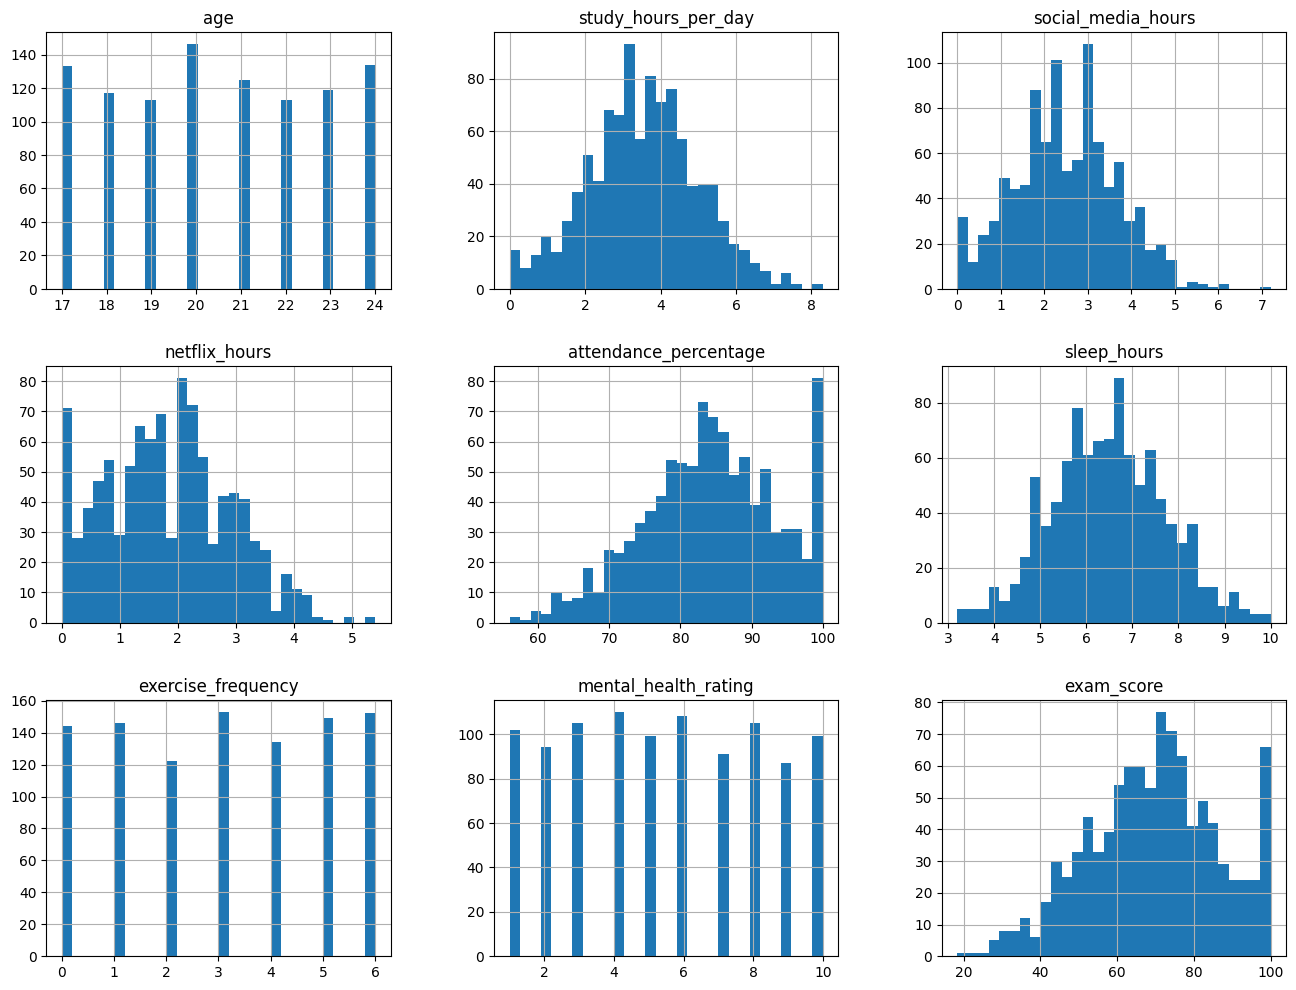

study_hours_per_day: 0.05425310140811603
social_media_hours: 0.11980520318308562
netflix_hours: 0.23715439564540441
attendance_percentage: -0.23781042684597256
sleep_hours: 0.09148397227093791
exam_score: -0.15635065547132798


In [114]:
df_part = df_simple_clean.select_dtypes(include=['int64', 'float64'])
ax_list = df_part.hist(figsize=(16, 12), bins=30)
plt.show()
for col in df_part.columns.to_list():
  if len(df_part[col].value_counts().index.to_list()) > 10:
    print(f'{col}: {df_part[col].skew()}')

In [37]:
pd.cut(df_part['sleep_hours'],[0, 6, 8, 10], labels=['less than 6', '6 to 8', 'more than 8']).value_counts()

,count
sleep_hours,
6 to 8,529
less than 6,368
more than 8,103


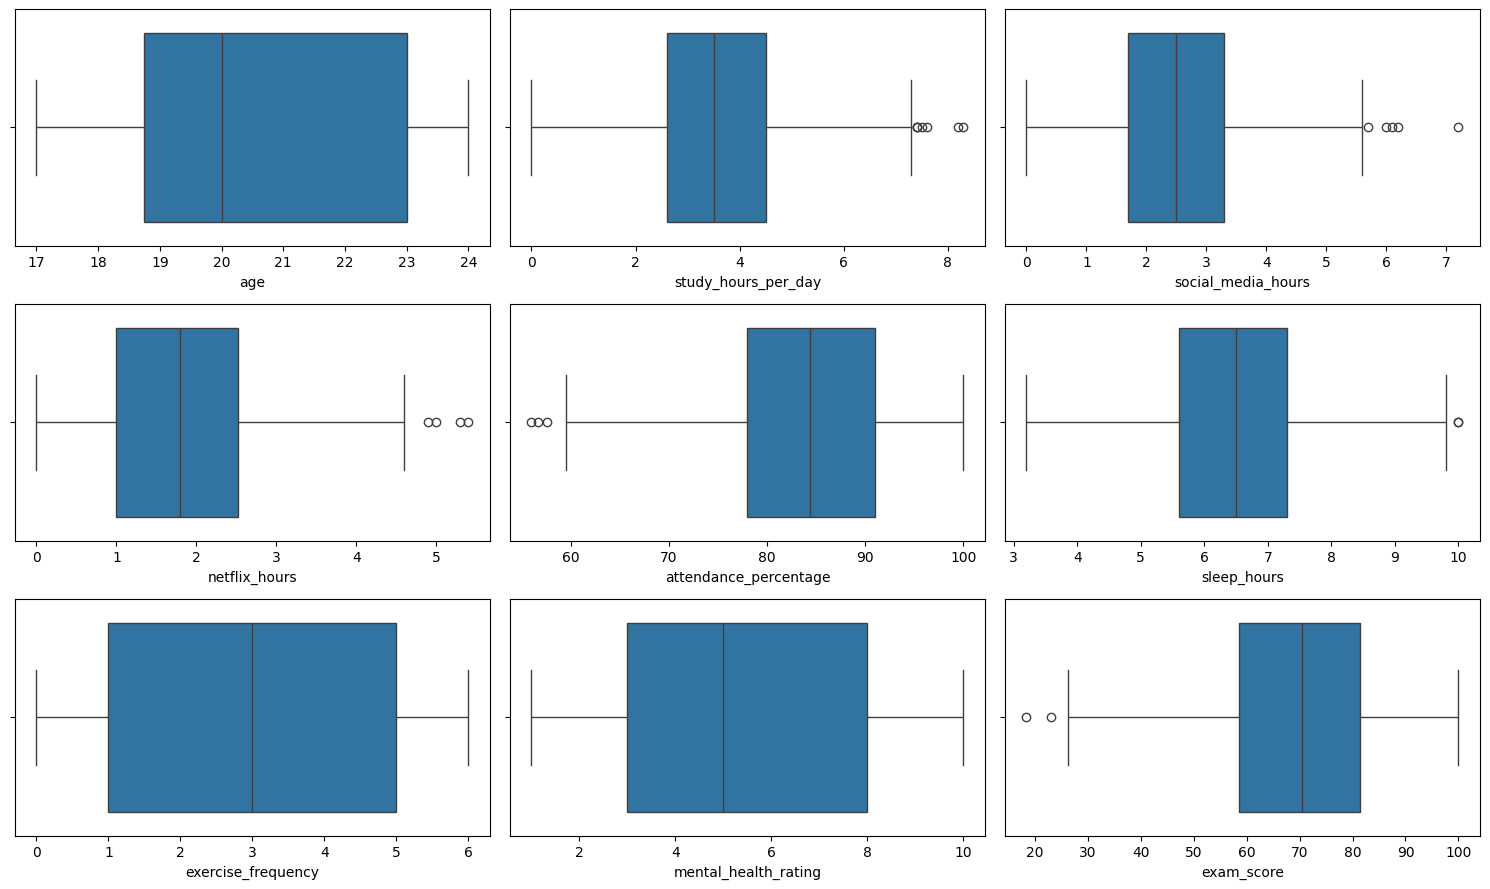

In [27]:
fig, axes = plt.subplots(3, 3, figsize=(5*3, 3*3))
cols = df_part.columns.to_list()
for i, ax in enumerate(axes.flatten()):
  sns.boxplot(x=df_part[cols[i]], ax=ax)

plt.tight_layout()
plt.show()

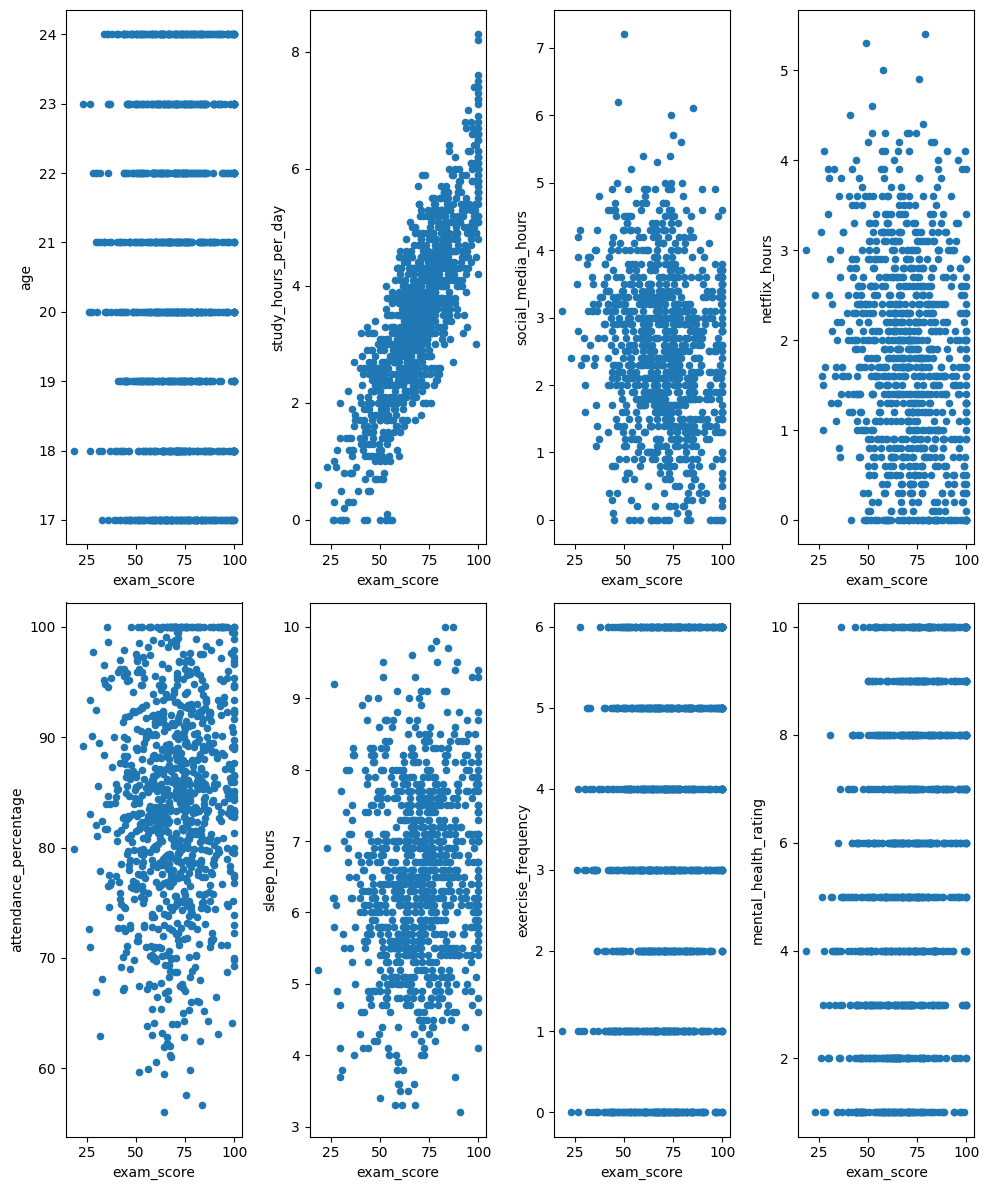

In [44]:
fig, axes = plt.subplots(2, 4, figsize=(5*2, 3*4))
cols = df_part.columns.to_list()
cols.remove('exam_score')
for i, ax in enumerate(axes.flatten()):
  df_part.plot.scatter(y=cols[i], x='exam_score', ax=ax)

plt.tight_layout()
plt.show()

,exam_score
age,-0.008907
study_hours_per_day,0.825419
social_media_hours,-0.166733
netflix_hours,-0.171779
attendance_percentage,0.089836
sleep_hours,0.121683
exercise_frequency,0.160107
mental_health_rating,0.321523


<Axes: >

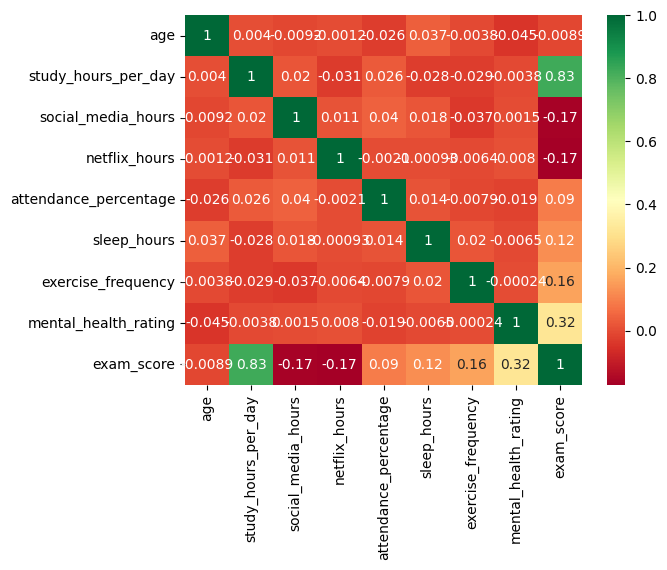

In [117]:
display(df_part.corr()['exam_score'][:-1])
sns.heatmap(df_part.corr(),annot=True,cmap='RdYlGn')

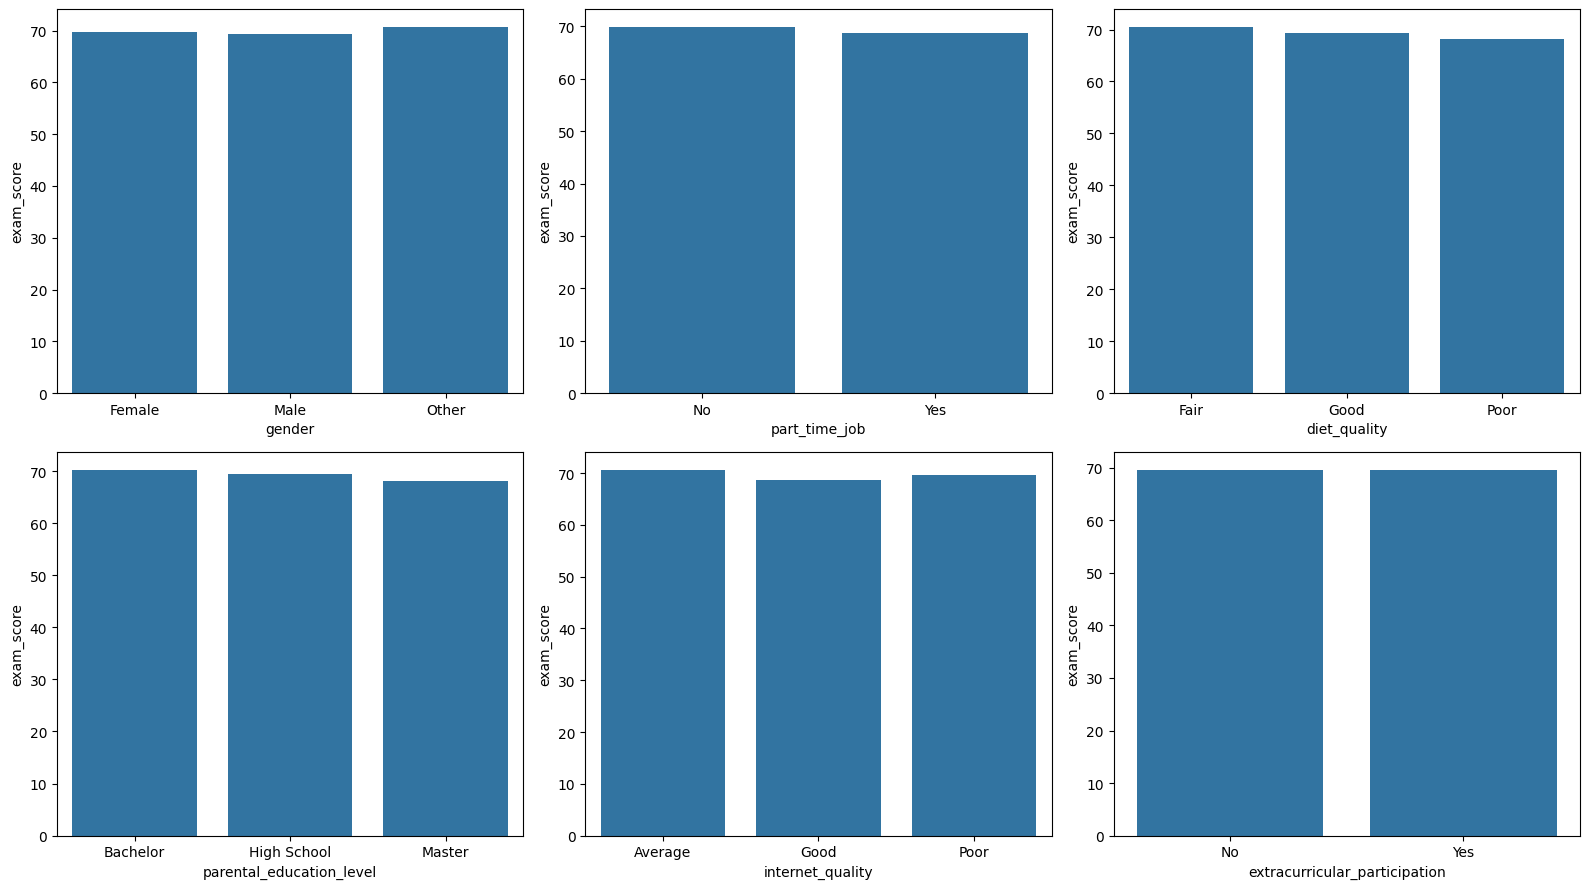

In [98]:
fig, axes = plt.subplots(2, 3, figsize=(8*2, 3*3))
cols = df_object_part.columns.to_list()
for i, ax in enumerate(axes.flatten()):
  col = cols[i]
  d = df.groupby(col)['exam_score'].mean()
  sns.barplot(d, ax=ax)
plt.tight_layout()
plt.show()

<ipython-input-97-20a5f0d2e9a9>:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(t_df, hist=False, ax=ax)
<ipython-input-97-20a5f0d2e9a9>:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(t_df, hist=False, ax=ax)
<ipython-input-97-20a5f0d2e9a9>:9: UserWarning: 

`distplot` is a 

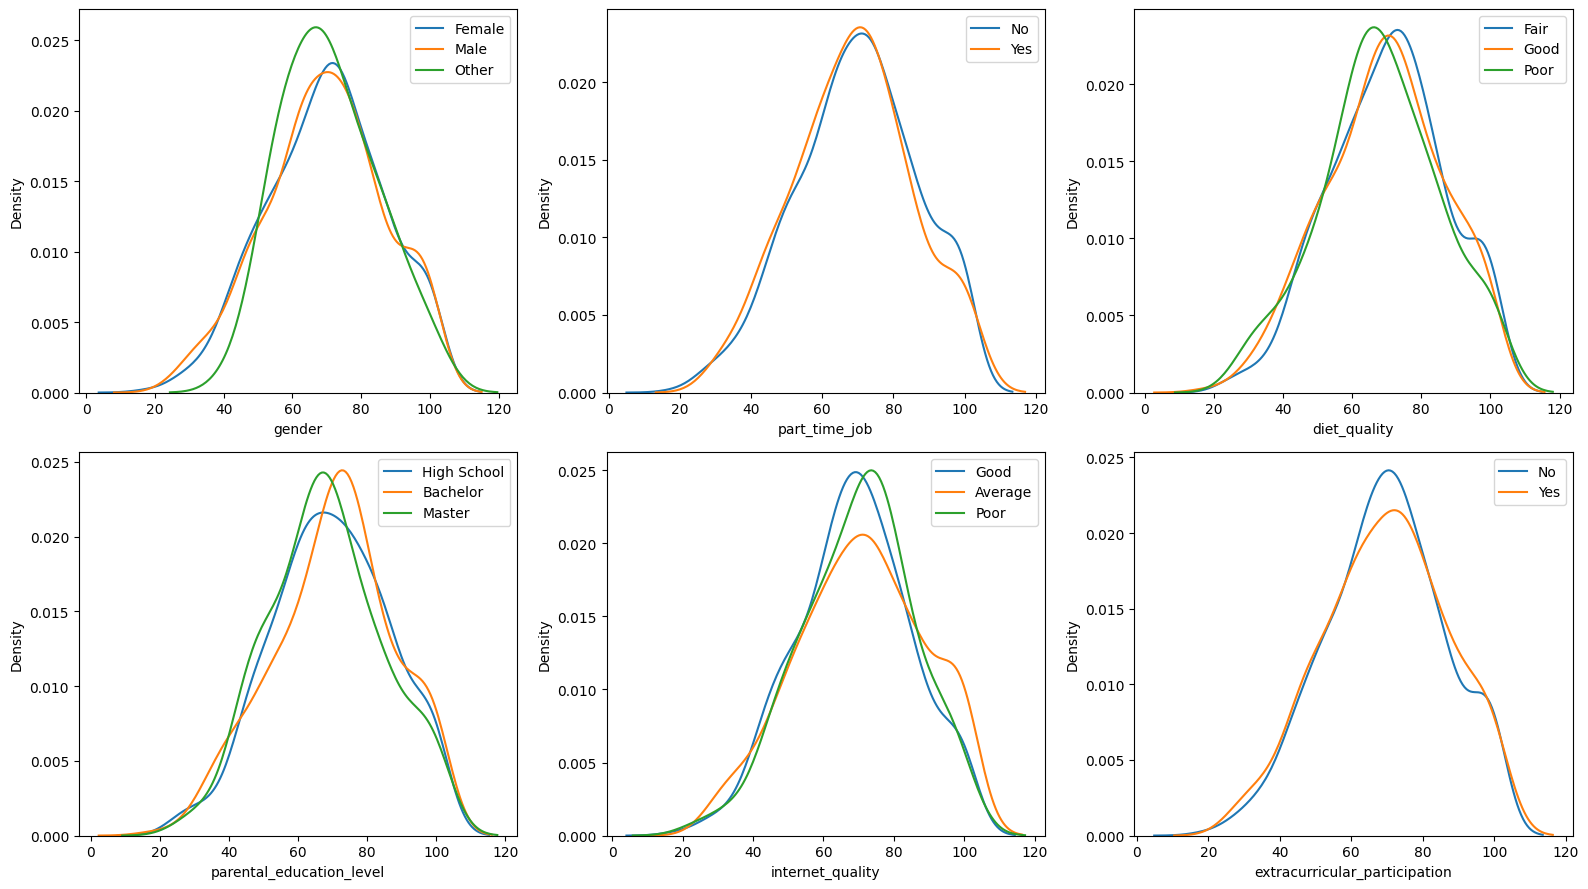

In [97]:
fig, axes = plt.subplots(2, 3, figsize=(8*2, 3*3))
cols = df_object_part.columns.to_list()
for i, ax in enumerate(axes.flatten()):
  col = cols[i]
  type_value = df_object_part[col].value_counts().index.to_list()

  for t in type_value:
    t_df = df.loc[df_object_part[col]==t, 'exam_score'].values
    sns.distplot(t_df, hist=False, ax=ax)
  ax.set_xlabel(col)
  ax.legend(type_value)

plt.tight_layout()
plt.show()

In [139]:
df_part['score_level'] = pd.cut(df_part['exam_score'], [0, 59.9, 79.9, 100], labels=['Fail', 'Moderate', 'Good'])
df_part.head()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score,score_level
0,23,0.0,1.2,1.1,85.0,8.0,6,8,56.2,Fail
1,20,6.9,2.8,2.3,97.3,4.6,6,8,100.0,Good
2,21,1.4,3.1,1.3,94.8,8.0,1,1,34.3,Fail
3,23,1.0,3.9,1.0,71.0,9.2,4,1,26.8,Fail
4,19,5.0,4.4,0.5,90.9,4.9,3,1,66.4,Moderate


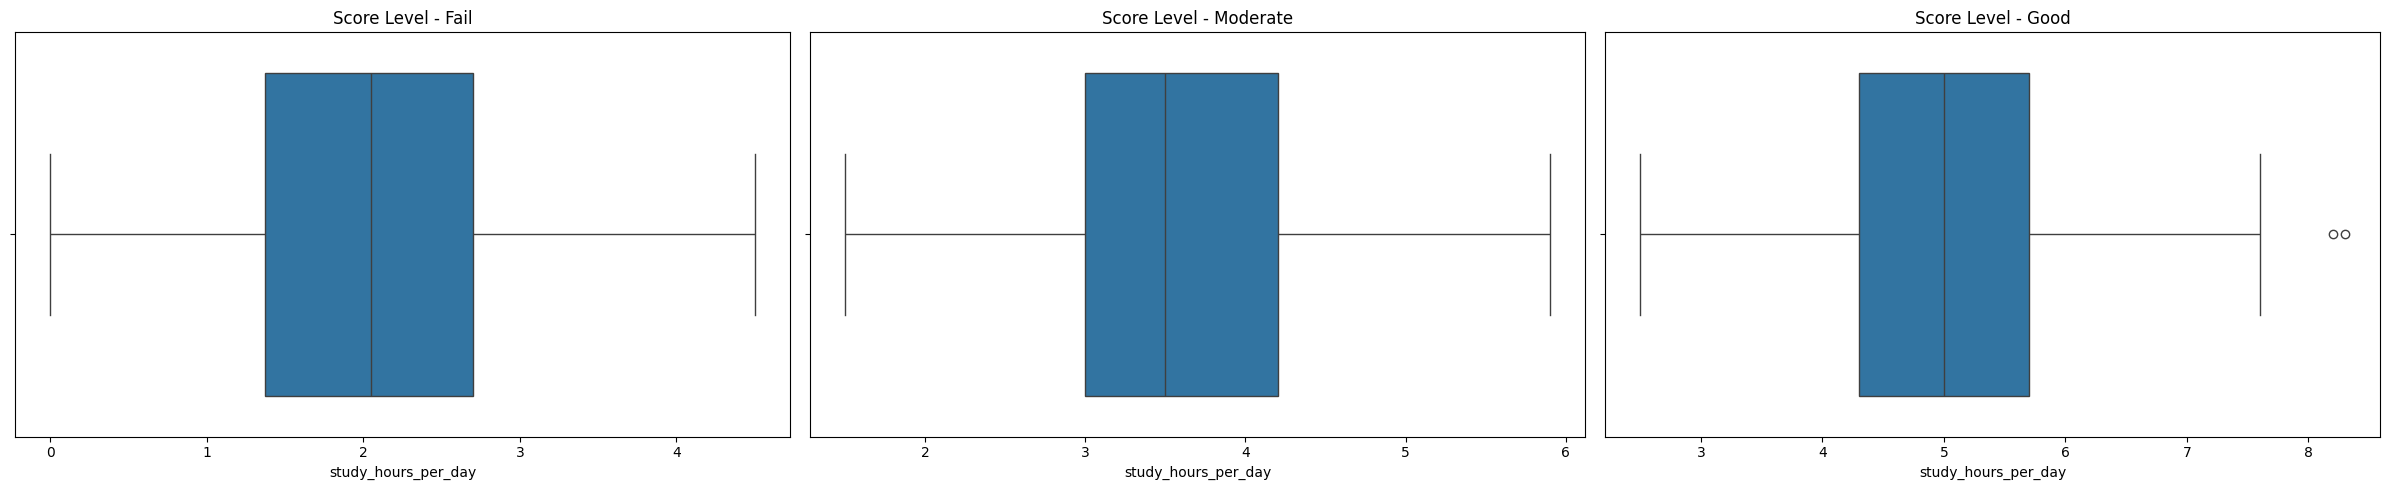

In [140]:
fig, axes = plt.subplots(1, 3, figsize=(8*3, 5))
score_level = ['Fail', 'Moderate', 'Good']
for i, ax in enumerate(axes.flatten()):
  ax.set_xlabel('study_hours_per_day')
  ax.set_title(f'Score Level - {score_level[i]}')
  sns.boxplot(x=df_part.loc[df_part['score_level']==score_level[i], 'study_hours_per_day'].values, ax=ax)


plt.tight_layout()
plt.show()

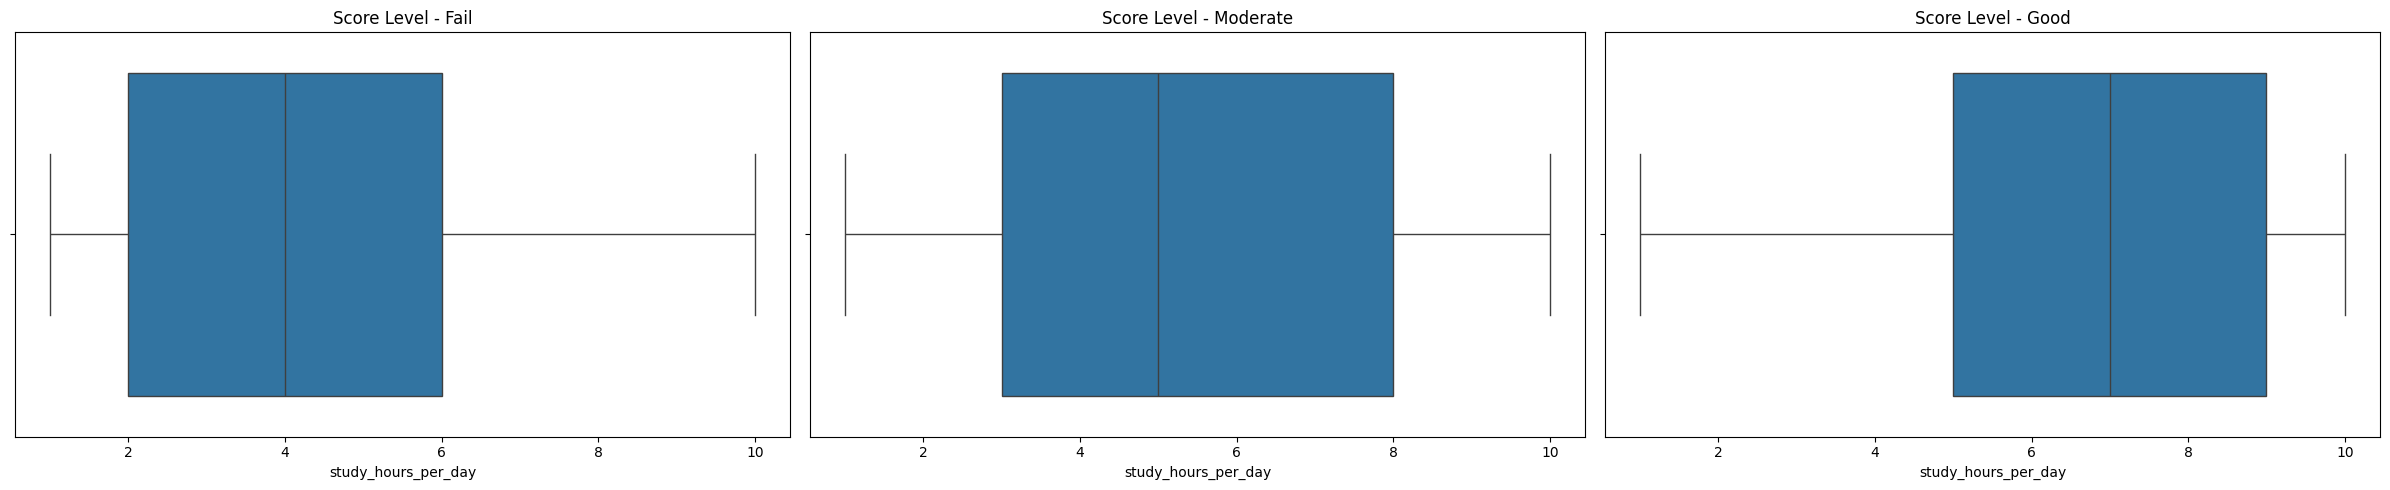

In [141]:
fig, axes = plt.subplots(1, 3, figsize=(8*3, 5))
score_level = ['Fail', 'Moderate', 'Good']
for i, ax in enumerate(axes.flatten()):
  ax.set_xlabel('study_hours_per_day')
  ax.set_title(f'Score Level - {score_level[i]}')
  sns.boxplot(x=df_part.loc[df_part['score_level']==score_level[i], 'mental_health_rating'].values, ax=ax)


plt.tight_layout()
plt.show()

In [5]:
df_part = df[df['parental_education_level'].notnull()].select_dtypes(include=['int64', 'float64'])
df_part.drop(columns=['exam_score'], inplace=True)
df_part['parental_education_level'] = df[df['parental_education_level'].notnull()]['parental_education_level']
df_part = df_part.set_index('parental_education_level').stack().to_frame().reset_index().rename(columns={'level_1':'Measure', 0:'Value'})
df_part

,parental_education_level,Measure,Value
0,Master,age,23.0
1,Master,study_hours_per_day,0.0
2,Master,social_media_hours,1.2
3,Master,netflix_hours,1.1
4,Master,attendance_percentage,85.0
...,...,...,...
7267,Bachelor,netflix_hours,1.9
7268,Bachelor,attendance_percentage,89.4
7269,Bachelor,sleep_hours,7.1
7270,Bachelor,exercise_frequency,2.0


<Axes: xlabel='Value', ylabel='Measure'>

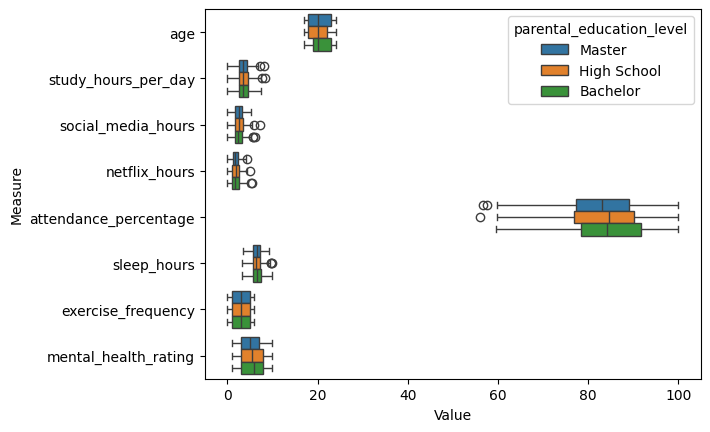

In [6]:
sns.boxplot(data=df_part, y='Measure', x='Value', hue='parental_education_level')

In [7]:
median_df = df.groupby('parental_education_level')[['age', 'exercise_frequency', 'mental_health_rating']].median()
median_df

,age,exercise_frequency,mental_health_rating
parental_education_level,,,
Bachelor,20.0,3.0,6.0
High School,20.0,3.0,5.5
Master,20.0,3.0,5.0


In [8]:
from scipy.spatial.distance import cdist
missing_data = df.loc[df['parental_education_level'].isnull(), ['age', 'exercise_frequency', 'mental_health_rating']].values
category = median_df.index.to_list()
median_values = median_df.values
distances = cdist(missing_data, median_values, metric='euclidean')
nearest_category = [category[i] for i in np.argmin(distances, axis=1)]
df.loc[df['parental_education_level'].isnull(), ['parental_education_level']] = nearest_category
df.isnull().sum()

,0
student_id,0
age,0
gender,0
study_hours_per_day,0
social_media_hours,0
netflix_hours,0
part_time_job,0
attendance_percentage,0
sleep_hours,0
diet_quality,0


<Axes: xlabel='Value', ylabel='Measure'>

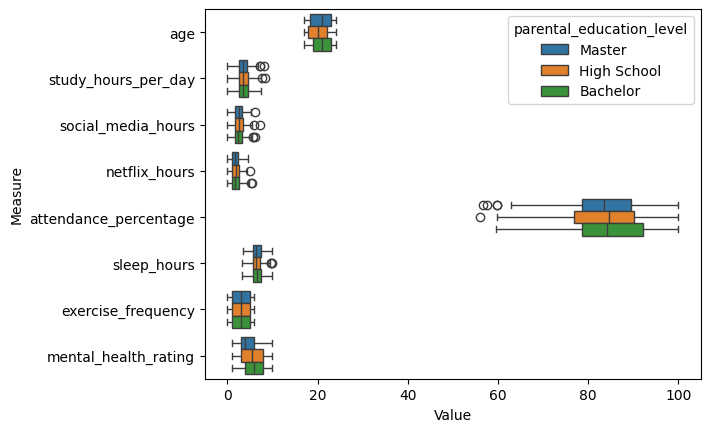

In [9]:
df_part = df[df['parental_education_level'].notnull()].select_dtypes(include=['int64', 'float64'])
df_part.drop(columns=['exam_score'], inplace=True)
df_part['parental_education_level'] = df[df['parental_education_level'].notnull()]['parental_education_level']
df_part = df_part.set_index('parental_education_level').stack().to_frame().reset_index().rename(columns={'level_1':'Measure', 0:'Value'})
sns.boxplot(data=df_part, y='Measure', x='Value', hue='parental_education_level')